## 3.3 Basis Risk

The early hedge examples looked almost “too perfect”. Hull explains why:

A hedge is imperfect because:
1. The asset being hedged may not be exactly the same as the futures underlying (cross-hedging).
2. The exact hedge horizon may be uncertain (timing mismatch).
3. The futures position might be closed out before the delivery month.

These issues create **basis risk**.

### The Basis (Hull definition)

Hull defines the **basis** as:

$$
\text{Basis} = S - F
$$

where:
- $S$ = spot price of the asset
- $F$ = futures price of the contract used for hedging

Notation over time:
- At time $t_1$: $S_1, F_1$, basis $b_1 = S_1 - F_1$
- At time $t_2$: $S_2, F_2$, basis $b_2 = S_2 - F_2$

Even if $S$ and $F$ move in the same direction, they may not move by exactly the same amount,
so the basis changes.

### Effective price with a hedge (Hull-level result)

Assume you hedge at $t_1$ and close out at $t_2$.

**Short hedge** (you will sell the asset at $t_2$):
- You sell the asset at $S_2$
- Futures profit (short) $\approx F_1 - F_2$

Effective selling price:

$$
S_2 + (F_1 - F_2)
= F_1 + (S_2 - F_2)
= F_1 + b_2
$$

**Long hedge** (you will buy the asset at $t_2$):
- You buy the asset at $S_2$
- Futures profit (long) $\approx F_2 - F_1$

Effective purchase price:

$$
S_2 - (F_2 - F_1)
= F_1 + (S_2 - F_2)
= F_1 + b_2
$$

**Key takeaway:**
- $F_1$ is known at hedge initiation.
- $b_2$ is uncertain when you start the hedge.

That uncertainty is **basis risk**.

In [1]:
# Example values (toy but directly matching the formula style)
S1, F1 = 2.50, 2.20
S2, F2 = 2.00, 1.90

b1 = S1 - F1
b2 = S2 - F2

effective_price = F1 + b2

print("=== Basis risk example ===")
print(f"b1 = S1 - F1 = {S1:.2f} - {F1:.2f} = {b1:.2f}")
print(f"b2 = S2 - F2 = {S2:.2f} - {F2:.2f} = {b2:.2f}")
print(f"Effective price with hedge = F1 + b2 = {F1:.2f} + {b2:.2f} = {effective_price:.2f}")

=== Basis risk example ===
b1 = S1 - F1 = 2.50 - 2.20 = 0.30
b2 = S2 - F2 = 2.00 - 1.90 = 0.10
Effective price with hedge = F1 + b2 = 2.20 + 0.10 = 2.30


### Why basis strengthening/weakening matters (intuition)

Since the effective price is approximately:

$$
\text{Effective price} \approx F_1 + b_2,
$$

the hedge outcome improves or worsens depending on what happens to the basis.

- If the basis increases ($b_2$ larger) → effective price increases.
- If the basis decreases ($b_2$ smaller) → effective price decreases.

Hull calls:
- an increase in basis: **strengthening of the basis**
- a decrease in basis: **weakening of the basis**

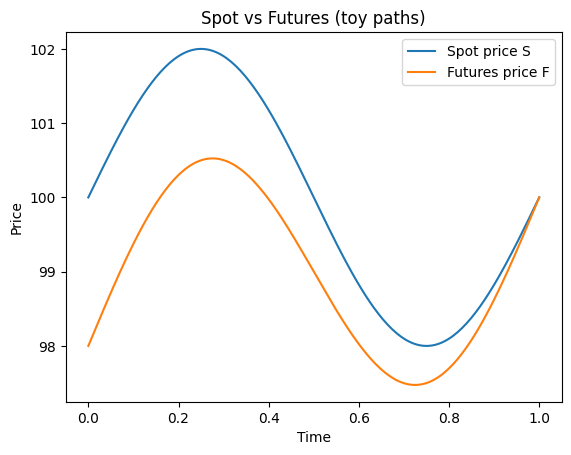

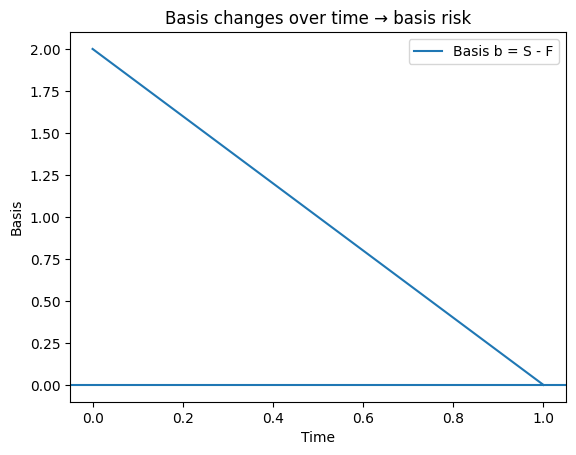

In [2]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 1, 200)
spot = 100 + 2*np.sin(2*np.pi*t)
futures = spot - (2*(1-t))  # basis starts positive then changes (toy)

basis = spot - futures

plt.figure()
plt.plot(t, spot, label="Spot price S")
plt.plot(t, futures, label="Futures price F")
plt.xlabel("Time")
plt.ylabel("Price")
plt.title("Spot vs Futures (toy paths)")
plt.legend()
plt.show()

plt.figure()
plt.plot(t, basis, label="Basis b = S - F")
plt.axhline(0)
plt.xlabel("Time")
plt.ylabel("Basis")
plt.title("Basis changes over time → basis risk")
plt.legend()
plt.show()

## Choice of Contract (Hull)

Choosing the futures contract matters for basis risk. Hull says the choice has two components:

1. **Which underlying** (which futures contract) to use  
   - If there is a futures contract on the exact asset → easy choice.
   - Otherwise, pick a related contract with prices highly correlated (cross-hedge).

2. **Which delivery month**  
   - Basis risk tends to increase as the time gap between hedge close-out and delivery month increases.
   - Rule of thumb (Hull): choose a delivery month **after** the hedge expiration, and as close as possible.
   - Liquidity matters: nearby contracts are often more liquid, so hedgers may use them and “roll” forward.